# scl_exp_98 — Learned Representation Analysis

**Experiment**: "Kitchen Sink" — continuous attr subspaces with all structural losses enabled.

**Config highlights**: `ambient_dim=8`, `n_attr=2` (dims_per_attr=4), `n_obj=4`, `attr_force_orthogonal_basis=True`, `subspace_gumbel_sigmoid=False` (continuous), MLP encoder.

**Loss weights**: attr_sink=10, inv_prop=10, singleton=10, galois_attr=10, IC=10, repulsion_attr=1, repulsion_obj=1, rank_conservation=1, basis_ortho=1.

This notebook loads the final checkpoint (epoch 99) and generates visualizations to inspect the learned compositional structure:
1. Attribute basis vectors for all 9 abstract concepts
2. Attribute and object subspace ranks across cardinalities
3. Full lattice inclusion/exclusion heatmaps
4. Compositionality evidence: how multi-object concepts compose from singletons

In [ ]:
import os, sys, itertools, yaml, glob
import numpy as np
import cv2
import torch
import torch.nn.functional as F
from torchvision import transforms
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import LinearSegmentedColormap

sys.path.append("/mnt/home/ubuntu/workspace/code/compositional-representation-learning")
from pl_modules.SubspaceConceptLattice.SubspaceConceptLattice import SubspaceConceptLattice
from pl_modules.SubspaceConceptLattice.concept_utils import get_inclusion, ridge_projector

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 1. Load Model and Extract Concepts

In [ ]:
# Load config and final checkpoint
config_path = "/mnt/home/ubuntu/workspace/code/compositional-representation-learning/configs/SubspaceConceptLattice/scl_exp_98.yaml"
ckpt_dir = "/mnt/home/ubuntu/workspace/experiment_root_dir/SubspaceConceptLattice/scl_exp_98/scl_exp_98___2026-04-07__14-59-33/checkpoints/"

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

# Load final checkpoint (epoch 99)
ckpt_path = os.path.join(ckpt_dir, "model-epoch=099.ckpt")
model = SubspaceConceptLattice.load_from_checkpoint(ckpt_path, config=config)
model.eval()
print(f"Loaded: {ckpt_path}")
print(f"ambient_dim={model.ambient_dim}, n_attr={model.n_attr}, n_obj={model.n_obj}")

In [ ]:
# Generate ideal images for all 4 singleton objects (2 colors x 2 shapes)
train_config = config["data"]["train"]["config"]
img_size = train_config["image_size"]
if isinstance(img_size, (list, tuple)):
    img_size_x, img_size_y = img_size
else:
    img_size_x = img_size_y = img_size

shapes = train_config["shapes"]   # ["circle", "square"]
colors = train_config["colors"]   # ["red", "blue"]
color_map = {"red": (255, 0, 0), "green": (0, 255, 0), "blue": (0, 0, 255)}
center_val = train_config["center_range"][0]
size_val = train_config["size_range"][0]
default_transform = transforms.Compose([transforms.ToTensor()])

def make_ideal_img(shape, color_name):
    img = np.zeros([img_size_x, img_size_y, 3], dtype=np.uint8)
    color = color_map[color_name]
    center = (center_val, center_val)
    if shape == "circle":
        cv2.circle(img, center, size_val // 2, color, -1)
    elif shape == "square":
        cv2.rectangle(img,
                      (center[0] - size_val // 2, center[1] - size_val // 2),
                      (center[0] + size_val // 2, center[1] + size_val // 2),
                      color, -1)
    return default_transform(img).to(model.device)

combinations = list(itertools.product(colors, shapes))
images = torch.stack([make_ideal_img(s, c) for c, s in combinations])
singleton_labels = [f"{c.capitalize()} {s.capitalize()}" for c, s in combinations]
num_singletons = len(combinations)

print(f"Singletons: {singleton_labels}")

# Show the 4 singleton images
fig, axes = plt.subplots(1, num_singletons, figsize=(3 * num_singletons, 3))
for i, (ax, label) in enumerate(zip(axes, singleton_labels)):
    ax.imshow(images[i].permute(1, 2, 0).cpu().numpy())
    ax.set_title(label, fontsize=12)
    ax.axis("off")
plt.suptitle("Singleton Objects", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Extract perceptual representations and build all 9 formal concepts
with torch.no_grad():
    R = model.perceptual_encoder(images)  # (4, num_patches, embed_dim)

# Define the 9 concepts of the lattice:
#   Card 4: Universal (all 4 objects)
#   Card 2: Red, Blue, Circle, Square (attribute-level groups)
#   Card 1: Red Circle, Red Square, Blue Circle, Blue Square (singletons)
concept_defs = {}
concept_defs["Universal"] = list(range(num_singletons))

for color in colors:
    concept_defs[f"{color.capitalize()}"] = [
        i for i, (c, s) in enumerate(combinations) if c == color
    ]
for shape in shapes:
    concept_defs[f"{shape.capitalize()}"] = [
        i for i, (c, s) in enumerate(combinations) if s == shape
    ]
for i, (c, s) in enumerate(combinations):
    concept_defs[f"{c.capitalize()} {s.capitalize()}"] = [i]

concept_labels = list(concept_defs.keys())
concept_cardinalities = {name: len(indices) for name, indices in concept_defs.items()}

# Extract X_attr, X_obj, P_attr, P_obj for each concept
concepts = {}
with torch.no_grad():
    for name, indices in concept_defs.items():
        subset = R[indices].unsqueeze(0)  # (1, k, num_patches, embed_dim)
        X_attr, X_obj, P_attr, P_obj = model.concept_encoder(subset)
        concepts[name] = {
            "X_attr": X_attr.squeeze(0).cpu(),   # (n_attr, ambient_dim)
            "X_obj": X_obj.squeeze(0).cpu(),      # (n_obj, ambient_dim)
            "P_attr": P_attr.squeeze(0).cpu(),    # (D, D)
            "P_obj": P_obj.squeeze(0).cpu(),      # (D, D)
            "cardinality": len(indices),
            "indices": indices,
        }

# Also get singleton reconstructions
with torch.no_grad():
    X_attr_singletons = torch.stack([concepts[name]["X_attr"] for name in concept_labels if concept_cardinalities[name] == 1])
    X_attr_dec = model.concept_encoder.attr_dec(X_attr_singletons.to(model.device))
    recon_images = model.decoder(X_attr_dec).cpu()

print(f"Extracted {len(concepts)} concepts: {concept_labels}")
print(f"Cardinalities: { {k: v for k, v in concept_cardinalities.items()} }")

In [ ]:
# Show singleton reconstructions
singleton_names = [name for name in concept_labels if concept_cardinalities[name] == 1]
fig, axes = plt.subplots(2, num_singletons, figsize=(3 * num_singletons, 6))
for i, name in enumerate(singleton_names):
    idx = concept_defs[name][0]
    axes[0, i].imshow(images[idx].permute(1, 2, 0).cpu().numpy().clip(0, 1))
    axes[0, i].set_title(name, fontsize=11)
    axes[0, i].axis("off")
    axes[1, i].imshow(recon_images[i].permute(1, 2, 0).numpy().clip(0, 1))
    axes[1, i].set_title("Reconstructed", fontsize=10)
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Reconstructed", fontsize=12)
plt.suptitle("Singleton Reconstructions (from attr subspace)", fontsize=14)
plt.tight_layout()
plt.show()

## 2. Attribute Basis Vectors for All 9 Concepts

Each concept has `n_attr=2` basis vectors in `ambient_dim=8`. With `attr_force_orthogonal_basis=True`, basis 0 lives in dims [0:4] and basis 1 in dims [4:8]. We visualize all 9 concepts grouped by cardinality (singletons, pairs, universal).

In [ ]:
# Attribute basis vectors for all 9 concepts — grouped by cardinality
ordered_names = (
    [n for n in concept_labels if concept_cardinalities[n] == 1] +   # singletons
    [n for n in concept_labels if concept_cardinalities[n] == 2] +   # pairs
    [n for n in concept_labels if concept_cardinalities[n] == 4]     # universal
)

n_concepts = len(ordered_names)
fig, axes = plt.subplots(n_concepts, 1, figsize=(10, 2.2 * n_concepts))

# Color coding for the two basis slots
slot_colors = ["#2196F3", "#FF9800"]  # blue for slot 0 (dims 0-3), orange for slot 1 (dims 4-7)
dim_labels = [f"d{i}" for i in range(model.ambient_dim)]

for i, name in enumerate(ordered_names):
    ax = axes[i]
    x_attr = concepts[name]["X_attr"].numpy()  # (n_attr, ambient_dim)
    card = concepts[name]["cardinality"]

    x = np.arange(model.ambient_dim)
    bar_width = 0.35
    for basis_idx in range(model.n_attr):
        ax.bar(x + basis_idx * bar_width, x_attr[basis_idx],
               width=bar_width, color=slot_colors[basis_idx],
               alpha=0.8, label=f"Slot {basis_idx} (dims {basis_idx*4}-{basis_idx*4+3})")

    # Add vertical separator between slots
    ax.axvline(x=3.5, color="gray", linestyle="--", alpha=0.4, linewidth=1)
    ax.set_ylabel("Value", fontsize=9)
    ax.set_xticks(x + bar_width / 2)
    ax.set_xticklabels(dim_labels, fontsize=9)
    title_suffix = f"  [card={card}]"
    ax.set_title(f"{name}{title_suffix}", fontsize=11, fontweight="bold", loc="left")
    ax.axhline(y=0, color="black", linewidth=0.5)
    if i == 0:
        ax.legend(fontsize=9, loc="upper right")

plt.suptitle("Attribute Basis Vectors (X_attr) for All 9 Concepts", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3. Attribute & Object Subspace Ranks

The rank of a projector `P = X^T(XX^T + lbd*I)^{-1}X` measures the effective dimensionality of the subspace. Expected behavior:
- **Attr ranks**: Singletons high (near 2.0), pairs lower, universal lowest (inverse proportionality with cardinality)
- **Obj ranks**: Singletons ~1.0, pairs ~2.0, universal ~4.0 (direct proportionality with cardinality)

In [ ]:
# Compute ranks for all concepts
attr_ranks = {}
obj_ranks = {}
for name in ordered_names:
    attr_ranks[name] = torch.trace(concepts[name]["P_attr"]).item()
    obj_ranks[name] = torch.trace(concepts[name]["P_obj"]).item()

# Print table
print(f"{'Concept':<22} {'Card':>4}  {'Attr Rank':>10}  {'Obj Rank':>10}")
print("-" * 55)
for name in ordered_names:
    print(f"{name:<22} {concept_cardinalities[name]:>4}  {attr_ranks[name]:>10.4f}  {obj_ranks[name]:>10.4f}")

# Bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Group by cardinality with color coding
card_colors = {1: "#4CAF50", 2: "#2196F3", 4: "#F44336"}
bar_colors = [card_colors[concept_cardinalities[n]] for n in ordered_names]

x_pos = np.arange(len(ordered_names))

bars1 = ax1.bar(x_pos, [attr_ranks[n] for n in ordered_names], color=bar_colors, alpha=0.85, edgecolor="black", linewidth=0.5)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(ordered_names, rotation=45, ha="right", fontsize=9)
ax1.set_ylabel("Rank (trace of projector)")
ax1.set_title("Attribute Subspace Ranks", fontsize=13)
ax1.axhline(y=model.n_attr, color="red", linestyle="--", alpha=0.5, label=f"max rank = {model.n_attr}")
ax1.legend(fontsize=9)
# Annotate values
for bar, val in zip(bars1, [attr_ranks[n] for n in ordered_names]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{val:.2f}", ha="center", va="bottom", fontsize=8)

bars2 = ax2.bar(x_pos, [obj_ranks[n] for n in ordered_names], color=bar_colors, alpha=0.85, edgecolor="black", linewidth=0.5)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(ordered_names, rotation=45, ha="right", fontsize=9)
ax2.set_ylabel("Rank (trace of projector)")
ax2.set_title("Object Subspace Ranks", fontsize=13)
ax2.axhline(y=model.n_obj, color="red", linestyle="--", alpha=0.5, label=f"max rank = {model.n_obj}")
ax2.legend(fontsize=9)
for bar, val in zip(bars2, [obj_ranks[n] for n in ordered_names]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{val:.2f}", ha="center", va="bottom", fontsize=8)

# Add cardinality legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=card_colors[k], label=f"Card {k}") for k in sorted(card_colors)]
fig.legend(handles=legend_elements, loc="upper center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.show()

## 4. Full Lattice Inclusion Heatmaps

Visualize the full NxN inclusion matrices for both attribute and object subspaces across all 9 concepts. The Galois connection predicts:
- If `S_a^attr` is included in `S_b^attr`, then `S_b^obj` should be included in `S_a^obj` (contravariance)
- Singletons' attr subspaces should be SUPERsets of their parent group subspaces (attr inclusion reverses with cardinality)

In [ ]:
# Compute full NxN inclusion matrices for all 9 concepts
N = len(ordered_names)
P_attr_all = torch.stack([concepts[n]["P_attr"] for n in ordered_names])  # (N, D, D)
P_obj_all = torch.stack([concepts[n]["P_obj"] for n in ordered_names])    # (N, D, D)

attr_incl = np.zeros((N, N))
obj_incl = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        # incl(i subset of j) — how much of i is contained in j
        attr_incl[i, j] = get_inclusion(
            P_attr_all[i].unsqueeze(0), P_attr_all[j].unsqueeze(0)
        ).item()
        obj_incl[i, j] = get_inclusion(
            P_obj_all[i].unsqueeze(0), P_obj_all[j].unsqueeze(0)
        ).item()

# Plot both heatmaps side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(attr_incl, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1,
            xticklabels=ordered_names, yticklabels=ordered_names, ax=ax1,
            cbar_kws={"label": "Inclusion score"})
ax1.set_title("Attribute Inclusion: incl(row $\\subseteq$ col)", fontsize=13)
ax1.set_xlabel("Column (superset candidate)")
ax1.set_ylabel("Row (subset candidate)")
ax1.tick_params(axis='x', rotation=45)
ax1.tick_params(axis='y', rotation=0)

sns.heatmap(obj_incl, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1,
            xticklabels=ordered_names, yticklabels=ordered_names, ax=ax2,
            cbar_kws={"label": "Inclusion score"})
ax2.set_title("Object Inclusion: incl(row $\\subseteq$ col)", fontsize=13)
ax2.set_xlabel("Column (superset candidate)")
ax2.set_ylabel("Row (subset candidate)")
ax2.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

## 5. Galois Connection Verification

The Galois connection is the core structural property: for any two concepts A, B:
- If `S_A^attr ⊆ S_B^attr` then `S_B^obj ⊆ S_A^obj`

We verify this for all concept pairs where at least one has a proper inclusion relationship (i.e., one is a parent/child in the lattice hierarchy).

In [ ]:
# Galois connection verification
# For every pair: check if attr_incl(A ⊆ B) > threshold implies obj_incl(B ⊆ A) is high
# This is the contravariance property

# Define the expected parent-child relationships in the lattice
# Parent -> children (parent's objects are superset of child's objects)
lattice_edges = []  # (parent_name, child_name) where parent has MORE objects
for name_a in ordered_names:
    for name_b in ordered_names:
        if name_a == name_b:
            continue
        # Check if A's objects are a strict superset of B's objects
        set_a = set(concept_defs[name_a])
        set_b = set(concept_defs[name_b])
        if set_b < set_a:  # strict subset
            lattice_edges.append((name_a, name_b))

print("Expected lattice edges (parent -> child, parent has more objects):")
print(f"{'Parent (more objects)':<22} {'Child (fewer objects)':<22} "
      f"{'Attr: child⊆parent':>18} {'Obj: parent⊆child':>18} {'Galois OK?':>10}")
print("-" * 95)

galois_violations = 0
for parent, child in lattice_edges:
    pi = ordered_names.index(parent)
    ci = ordered_names.index(child)
    # Galois: if child has MORE attributes (child_attr ⊇ parent_attr),
    # then parent has MORE objects (parent_obj ⊇ child_obj)
    # Check: incl(parent_attr ⊆ child_attr) and incl(child_obj ⊆ parent_obj)
    attr_child_contains_parent = attr_incl[pi, ci]  # parent_attr ⊆ child_attr
    obj_parent_contains_child = obj_incl[ci, pi]     # child_obj ⊆ parent_obj
    ok = "YES" if (attr_child_contains_parent > 0.7 and obj_parent_contains_child > 0.7) else "NO"
    if ok == "NO":
        galois_violations += 1
    print(f"{parent:<22} {child:<22} {attr_child_contains_parent:>18.3f} {obj_parent_contains_child:>18.3f} {ok:>10}")

print(f"\nGalois violations: {galois_violations}/{len(lattice_edges)}")

## 6. Lattice Diagram with Hasse Edges

Visualize the concept lattice as a proper Hasse diagram. Node size reflects cardinality, edges connect parent-child pairs (where parent has strictly more objects). Edge color encodes the Galois compliance (both attr and obj inclusions high = green).

In [ ]:
# Hasse diagram of the concept lattice
# Only draw edges for direct parent-child (no transitive edges)
# Direct: parent -> child where there's no intermediate concept

def is_direct_edge(parent, child, all_concepts):
    """Check if parent -> child is a direct (cover) relation in the lattice."""
    set_p = set(concept_defs[parent])
    set_c = set(concept_defs[child])
    if not (set_c < set_p):
        return False
    # Check there's no intermediate concept between them
    for mid in all_concepts:
        if mid == parent or mid == child:
            continue
        set_m = set(concept_defs[mid])
        if set_c < set_m and set_m < set_p:
            return False  # there's an intermediate
    return True

direct_edges = [(p, c) for p, c in lattice_edges if is_direct_edge(p, c, ordered_names)]

# Layout: y-position by cardinality level, x-position spread within each level
levels = {4: [], 2: [], 1: []}
for name in ordered_names:
    levels[concept_cardinalities[name]].append(name)

y_positions = {4: 3, 2: 2, 1: 1}
positions = {}
for card, names in levels.items():
    y = y_positions[card]
    n = len(names)
    for i, name in enumerate(names):
        x = (i - (n - 1) / 2) * 2.0
        positions[name] = (x, y)

fig, ax = plt.subplots(figsize=(12, 8))

# Draw edges first
for parent, child in direct_edges:
    pi = ordered_names.index(parent)
    ci = ordered_names.index(child)
    # Galois quality: min of the two inclusion directions
    attr_score = attr_incl[pi, ci]  # parent_attr ⊆ child_attr
    obj_score = obj_incl[ci, pi]    # child_obj ⊆ parent_obj
    galois_score = min(attr_score, obj_score)

    color = plt.cm.RdYlGn(galois_score)
    lw = 1.5 + 2.0 * galois_score

    x_p, y_p = positions[parent]
    x_c, y_c = positions[child]
    ax.annotate("", xy=(x_c, y_c + 0.15), xytext=(x_p, y_p - 0.15),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, mutation_scale=15))

    # Label the edge with scores
    mid_x = (x_p + x_c) / 2
    mid_y = (y_p + y_c) / 2
    ax.text(mid_x + 0.15, mid_y, f"A:{attr_score:.2f}\nO:{obj_score:.2f}",
            fontsize=7, ha="left", va="center", color="gray",
            bbox=dict(boxstyle="round,pad=0.15", facecolor="white", alpha=0.7, edgecolor="none"))

# Draw nodes
for name in ordered_names:
    x, y = positions[name]
    card = concept_cardinalities[name]
    node_size = 300 + card * 200

    # Node color by type
    if card == 1:
        nc = "#81C784"  # green for singletons
    elif card == 2:
        nc = "#64B5F6"  # blue for pairs
    else:
        nc = "#EF5350"  # red for universal

    ax.scatter(x, y, s=node_size, c=nc, edgecolors="black", linewidth=1.5, zorder=5)
    ax.text(x, y - 0.35, name, ha="center", va="top", fontsize=9, fontweight="bold")

    # Show ranks inside node
    ar = attr_ranks[name]
    orr = obj_ranks[name]
    ax.text(x, y + 0.02, f"A:{ar:.1f} O:{orr:.1f}", ha="center", va="center", fontsize=7)

ax.set_xlim(-5, 5)
ax.set_ylim(0.3, 3.7)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Concept Lattice (Hasse Diagram)\nEdge labels: A=attr incl(parent⊆child), O=obj incl(child⊆parent)",
             fontsize=13, pad=20)

# Legend for edge colors
sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn, norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.02, label="Galois compliance (min of both inclusions)")

plt.tight_layout()
plt.show()

## 7. Compositionality Evidence — Attribute Subspaces

The key claim of compositional representation learning: multi-object concepts should have attribute subspaces that are the **intersection** of their constituent singletons. We test:

1. **Intersection consistency**: For a pair concept (e.g., "Red" = {Red Circle, Red Square}), its attr projector should approximate the intersection of the two singleton attr projectors.
2. **Shared vs unique dimensions**: The shared subspace between two singletons of the same color should preserve the color dimension while dropping shape; same-shape should preserve shape while dropping color.

In [ ]:
# Intersection consistency test for attr subspaces
# For each pair concept, compare its learned P_attr with the intersection of its singletons

pair_concepts = [n for n in ordered_names if concept_cardinalities[n] == 2]

print("Intersection Consistency (Attr Subspace)")
print("=" * 80)

fig, axes = plt.subplots(len(pair_concepts), 3, figsize=(16, 4 * len(pair_concepts)))

for row, pair_name in enumerate(pair_concepts):
    children = concept_defs[pair_name]
    child_names = [ordered_names[ordered_names.index(n)] for n in ordered_names 
                   if concept_cardinalities[n] == 1 and concept_defs[n][0] in children]

    # Get singleton projectors
    P_i = concepts[child_names[0]]["P_attr"]
    P_j = concepts[child_names[1]]["P_attr"]
    P_pair_learned = concepts[pair_name]["P_attr"]

    # Compute intersection via alternating projection approximation
    P_intersection = 0.5 * (P_i @ P_j + P_j @ P_i)

    # Measure agreement
    incl_learned_in_inter = get_inclusion(P_pair_learned.unsqueeze(0), P_intersection.unsqueeze(0)).item()
    incl_inter_in_learned = get_inclusion(P_intersection.unsqueeze(0), P_pair_learned.unsqueeze(0)).item()
    rank_learned = torch.trace(P_pair_learned).item()
    rank_inter = torch.trace(P_intersection).item()

    print(f"\n{pair_name} = {child_names[0]} ∩ {child_names[1]}")
    print(f"  Learned rank: {rank_learned:.3f}, Intersection rank: {rank_inter:.3f}")
    print(f"  incl(learned ⊆ intersection): {incl_learned_in_inter:.3f}")
    print(f"  incl(intersection ⊆ learned): {incl_inter_in_learned:.3f}")

    # Visualize: P_pair_learned vs P_intersection as heatmaps
    ax_l = axes[row, 0]
    ax_i = axes[row, 1]
    ax_d = axes[row, 2]

    vmin = min(P_pair_learned.min().item(), P_intersection.min().item())
    vmax = max(P_pair_learned.max().item(), P_intersection.max().item())

    sns.heatmap(P_pair_learned.numpy(), ax=ax_l, cmap="coolwarm", center=0,
                vmin=vmin, vmax=vmax, square=True, cbar=False,
                xticklabels=False, yticklabels=False)
    ax_l.set_title(f"Learned P_attr\n({pair_name}, rank={rank_learned:.2f})", fontsize=10)

    sns.heatmap(P_intersection.numpy(), ax=ax_i, cmap="coolwarm", center=0,
                vmin=vmin, vmax=vmax, square=True, cbar=False,
                xticklabels=False, yticklabels=False)
    ax_i.set_title(f"Intersection P_attr\n({child_names[0]} ∩ {child_names[1]}, rank={rank_inter:.2f})", fontsize=10)

    diff = (P_pair_learned - P_intersection).numpy()
    sns.heatmap(diff, ax=ax_d, cmap="coolwarm", center=0, square=True, cbar=True,
                xticklabels=False, yticklabels=False)
    ax_d.set_title(f"Difference\n(Frobenius: {np.linalg.norm(diff):.3f})", fontsize=10)

plt.suptitle("Attr Intersection Consistency: Learned vs Computed from Singletons", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 8. Compositionality Evidence — Object Subspaces

For object subspaces, compositionality means **union**: the object subspace of a multi-object concept should be the union (span) of its constituent singletons' object subspaces.

In [ ]:
# Union consistency test for obj subspaces
# For each multi-object concept, compare its learned P_obj with the union (span) of singletons

multi_concepts = [n for n in ordered_names if concept_cardinalities[n] >= 2]

print("Union Consistency (Obj Subspace)")
print("=" * 80)

fig, axes = plt.subplots(len(multi_concepts), 3, figsize=(16, 4 * len(multi_concepts)))

for row, mc_name in enumerate(multi_concepts):
    children_idx = concept_defs[mc_name]
    child_names = [n for n in ordered_names if concept_cardinalities[n] == 1 and concept_defs[n][0] in children_idx]

    # Get singleton obj basis vectors and compute union projector
    X_obj_parts = [concepts[cn]["X_obj"] for cn in child_names]
    X_obj_union = torch.cat(X_obj_parts, dim=0)  # (k * n_obj, ambient_dim)
    P_union_computed = ridge_projector(X_obj_union.unsqueeze(0), lbd=model.lbd).squeeze(0)
    P_obj_learned = concepts[mc_name]["P_obj"]

    incl_learned_in_union = get_inclusion(P_obj_learned.unsqueeze(0), P_union_computed.unsqueeze(0)).item()
    incl_union_in_learned = get_inclusion(P_union_computed.unsqueeze(0), P_obj_learned.unsqueeze(0)).item()
    rank_learned = torch.trace(P_obj_learned).item()
    rank_union = torch.trace(P_union_computed).item()

    members_str = " ∪ ".join(child_names)
    print(f"\n{mc_name} = {members_str}")
    print(f"  Learned rank: {rank_learned:.3f}, Union rank: {rank_union:.3f}")
    print(f"  incl(learned ⊆ union): {incl_learned_in_union:.3f}")
    print(f"  incl(union ⊆ learned): {incl_union_in_learned:.3f}")

    ax_l = axes[row, 0]
    ax_u = axes[row, 1]
    ax_d = axes[row, 2]

    vmin = min(P_obj_learned.min().item(), P_union_computed.min().item())
    vmax = max(P_obj_learned.max().item(), P_union_computed.max().item())

    sns.heatmap(P_obj_learned.numpy(), ax=ax_l, cmap="coolwarm", center=0,
                vmin=vmin, vmax=vmax, square=True, cbar=False,
                xticklabels=False, yticklabels=False)
    ax_l.set_title(f"Learned P_obj\n({mc_name}, rank={rank_learned:.2f})", fontsize=10)

    sns.heatmap(P_union_computed.numpy(), ax=ax_u, cmap="coolwarm", center=0,
                vmin=vmin, vmax=vmax, square=True, cbar=False,
                xticklabels=False, yticklabels=False)
    ax_u.set_title(f"Union P_obj\n({members_str}, rank={rank_union:.2f})", fontsize=10)

    diff = (P_obj_learned - P_union_computed).numpy()
    sns.heatmap(diff, ax=ax_d, cmap="coolwarm", center=0, square=True, cbar=True,
                xticklabels=False, yticklabels=False)
    ax_d.set_title(f"Difference\n(Frobenius: {np.linalg.norm(diff):.3f})", fontsize=10)

plt.suptitle("Obj Union Consistency: Learned vs Computed from Singletons", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 9. Attribute Slot Disentanglement — Color vs Shape

With `attr_force_orthogonal_basis=True`, slot 0 (dims 0-3) and slot 1 (dims 4-7) are architecturally disjoint. If the model learns compositional representations, one slot should encode color and the other should encode shape.

We check: do same-color singletons share a slot's values while differing in the other?

In [ ]:
# Slot disentanglement analysis
# Compare cosine similarity of each slot's basis vector across singletons

singleton_X_attr = {name: concepts[name]["X_attr"] for name in ordered_names if concept_cardinalities[name] == 1}
singleton_list = list(singleton_X_attr.keys())
n_singletons = len(singleton_list)
dims_per_slot = model.concept_encoder.dims_per_slot  # [4, 4]

# Compute per-slot cosine similarity between all singleton pairs
for slot_idx in range(model.n_attr):
    d = dims_per_slot[slot_idx]
    offset = sum(dims_per_slot[:slot_idx])

    print(f"\n{'='*50}")
    print(f"Slot {slot_idx} (dims {offset}:{offset+d})")
    print(f"{'='*50}")

    # Extract slot values
    slot_vecs = {}
    for name in singleton_list:
        vec = singleton_X_attr[name][slot_idx, offset:offset+d]
        slot_vecs[name] = vec
        print(f"  {name}: [{', '.join(f'{v:.3f}' for v in vec.tolist())}]")

    # Cosine similarity matrix
    print(f"\n  Cosine similarity (slot {slot_idx}):")
    vecs = torch.stack([slot_vecs[n] for n in singleton_list])
    vecs_norm = F.normalize(vecs, p=2, dim=-1)
    cos_sim = (vecs_norm @ vecs_norm.T).numpy()

    print(f"  {'':>20}", end="")
    for n in singleton_list:
        print(f"{n:>20}", end="")
    print()
    for i, n_i in enumerate(singleton_list):
        print(f"  {n_i:>20}", end="")
        for j in range(n_singletons):
            print(f"{cos_sim[i,j]:>20.3f}", end="")
        print()

# Visualization: heatmap of per-slot similarities
fig, axes = plt.subplots(1, model.n_attr, figsize=(6 * model.n_attr, 5))

for slot_idx in range(model.n_attr):
    d = dims_per_slot[slot_idx]
    offset = sum(dims_per_slot[:slot_idx])
    vecs = torch.stack([singleton_X_attr[n][slot_idx, offset:offset+d] for n in singleton_list])
    vecs_norm = F.normalize(vecs, p=2, dim=-1)
    cos_sim = (vecs_norm @ vecs_norm.T).numpy()

    ax = axes[slot_idx]
    sns.heatmap(cos_sim, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
                xticklabels=singleton_list, yticklabels=singleton_list, ax=ax, square=True)
    ax.set_title(f"Slot {slot_idx} Cosine Similarity\n(dims {offset}:{offset+d})", fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle("Per-Slot Attribute Similarity — Does each slot encode one factor?", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Interpretation
print("\nExpected pattern for disentanglement:")
print("  If slot 0 = color: Red Circle ≈ Red Square, Blue Circle ≈ Blue Square")
print("  If slot 1 = shape: Red Circle ≈ Blue Circle, Red Square ≈ Blue Square")

## 10. Object Basis Vectors — Singleton Differentiation

For object subspaces, each singleton should occupy a distinct rank-1 subspace. We visualize the `n_obj=4` basis vectors for each singleton and check that different singletons use orthogonal directions.

In [ ]:
# Object basis vectors for all 9 concepts
fig, axes = plt.subplots(len(ordered_names), 1, figsize=(10, 2.2 * len(ordered_names)))

obj_colors = ["#E91E63", "#9C27B0", "#00BCD4", "#8BC34A"]  # 4 colors for 4 obj basis vectors

for i, name in enumerate(ordered_names):
    ax = axes[i]
    x_obj = concepts[name]["X_obj"].numpy()  # (n_obj, ambient_dim)
    card = concepts[name]["cardinality"]

    x = np.arange(model.ambient_dim)
    bar_width = 0.8 / model.n_obj
    for basis_idx in range(model.n_obj):
        ax.bar(x + basis_idx * bar_width, x_obj[basis_idx],
               width=bar_width, color=obj_colors[basis_idx],
               alpha=0.8, label=f"Obj basis {basis_idx}")

    ax.set_ylabel("Value", fontsize=9)
    ax.set_xticks(x + bar_width * (model.n_obj - 1) / 2)
    ax.set_xticklabels([f"d{j}" for j in range(model.ambient_dim)], fontsize=9)
    ax.set_title(f"{name}  [card={card}, obj_rank={obj_ranks[name]:.2f}]",
                 fontsize=11, fontweight="bold", loc="left")
    ax.axhline(y=0, color="black", linewidth=0.5)
    if i == 0:
        ax.legend(fontsize=8, loc="upper right", ncol=model.n_obj)

plt.suptitle("Object Basis Vectors (X_obj) for All 9 Concepts", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Singleton object subspace overlap matrix — are they orthogonal?
singleton_P_obj = torch.stack([concepts[n]["P_obj"] for n in singleton_list])
n_s = len(singleton_list)

obj_overlap = np.zeros((n_s, n_s))
for i in range(n_s):
    for j in range(n_s):
        # Frobenius inner product of projectors = trace(P_i @ P_j)
        obj_overlap[i, j] = torch.trace(singleton_P_obj[i] @ singleton_P_obj[j]).item()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(obj_overlap, annot=True, fmt=".3f", cmap="YlGnBu",
            xticklabels=singleton_list, yticklabels=singleton_list, ax=ax, square=True)
ax.set_title("Singleton Object Subspace Overlap\nTr(P_i @ P_j) — diagonal = rank, off-diag = overlap", fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

print("Ideal: diagonal ≈ 1.0 (rank-1), off-diagonal ≈ 0.0 (orthogonal)")

## 11. Summary Metrics Dashboard

Aggregate all the key structural metrics into a single view.

In [ ]:
# Summary dashboard
print("=" * 70)
print("SCL_EXP_98 — Summary Metrics")
print("=" * 70)

# 1. Rank spread
singleton_attr = [attr_ranks[n] for n in ordered_names if concept_cardinalities[n] == 1]
pair_attr = [attr_ranks[n] for n in ordered_names if concept_cardinalities[n] == 2]
universal_attr = [attr_ranks[n] for n in ordered_names if concept_cardinalities[n] == 4]
singleton_obj = [obj_ranks[n] for n in ordered_names if concept_cardinalities[n] == 1]
pair_obj = [obj_ranks[n] for n in ordered_names if concept_cardinalities[n] == 2]
universal_obj = [obj_ranks[n] for n in ordered_names if concept_cardinalities[n] == 4]

print(f"\nRank Statistics:")
print(f"  Attr — Singletons: {np.mean(singleton_attr):.3f} ± {np.std(singleton_attr):.3f}")
print(f"  Attr — Pairs:      {np.mean(pair_attr):.3f} ± {np.std(pair_attr):.3f}")
print(f"  Attr — Universal:  {np.mean(universal_attr):.3f}")
print(f"  Attr spread (singleton - universal): {np.mean(singleton_attr) - np.mean(universal_attr):.3f}")
print(f"  Obj  — Singletons: {np.mean(singleton_obj):.3f} ± {np.std(singleton_obj):.3f}")
print(f"  Obj  — Pairs:      {np.mean(pair_obj):.3f} ± {np.std(pair_obj):.3f}")
print(f"  Obj  — Universal:  {np.mean(universal_obj):.3f}")
print(f"  Obj spread (universal - singleton):  {np.mean(universal_obj) - np.mean(singleton_obj):.3f}")

# 2. Galois compliance
galois_scores = []
for parent, child in direct_edges:
    pi = ordered_names.index(parent)
    ci = ordered_names.index(child)
    galois_scores.append(min(attr_incl[pi, ci], obj_incl[ci, pi]))
print(f"\nGalois Compliance (direct edges):")
print(f"  Mean: {np.mean(galois_scores):.3f}, Min: {np.min(galois_scores):.3f}, Max: {np.max(galois_scores):.3f}")

# 3. Singleton obj orthogonality
off_diag = obj_overlap[~np.eye(n_s, dtype=bool)]
print(f"\nSingleton Obj Orthogonality:")
print(f"  Mean off-diagonal overlap: {np.mean(off_diag):.4f}")
print(f"  Max off-diagonal overlap:  {np.max(off_diag):.4f}")

# 4. Inverse proportionality check
from scipy import stats
cards = [concept_cardinalities[n] for n in ordered_names]
aranks = [attr_ranks[n] for n in ordered_names]
oranks = [obj_ranks[n] for n in ordered_names]
attr_corr, _ = stats.pearsonr(cards, aranks)
obj_corr, _ = stats.pearsonr(cards, oranks)
print(f"\nRank-Cardinality Correlation:")
print(f"  Attr vs Card (expect -1): {attr_corr:.3f}")
print(f"  Obj  vs Card (expect +1): {obj_corr:.3f}")

# Scatter plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
for name in ordered_names:
    c = concept_cardinalities[name]
    ax1.scatter(c, attr_ranks[name], s=100, zorder=5)
    ax1.annotate(name, (c, attr_ranks[name]), fontsize=7, ha="center", va="bottom", xytext=(0, 5),
                 textcoords="offset points")
    ax2.scatter(c, obj_ranks[name], s=100, zorder=5)
    ax2.annotate(name, (c, obj_ranks[name]), fontsize=7, ha="center", va="bottom", xytext=(0, 5),
                 textcoords="offset points")

ax1.set_xlabel("Cardinality")
ax1.set_ylabel("Attr Rank")
ax1.set_title(f"Attr Rank vs Cardinality (r={attr_corr:.3f})")
ax1.set_xticks([1, 2, 3, 4])

ax2.set_xlabel("Cardinality")
ax2.set_ylabel("Obj Rank")
ax2.set_title(f"Obj Rank vs Cardinality (r={obj_corr:.3f})")
ax2.set_xticks([1, 2, 3, 4])

plt.tight_layout()
plt.show()

## 12. Triplet (Cardinality-3) Concepts — Do They Collapse to Universal?

With only 4 singletons, every 3-element subset leaves out exactly 1 object. These triplets don't correspond to any natural attribute grouping — there's no single attribute shared by exactly 3 of {Red Circle, Red Square, Blue Circle, Blue Square}. In a well-structured lattice they should behave almost like the universal concept:
- **Obj rank ~3** (or close to 4 if the model can't distinguish them from universal)
- **Attr rank** very low (approaching universal), since the intersection of 3 diverse singletons retains almost nothing
- **Inclusion with Universal**: high in both directions — they should be nearly indistinguishable from the top element

This is the "missing level" of the lattice — the model was never explicitly trained on card-3 subsets (batch size = 8 limits combinations to what the forward pass samples), so this tests generalization of the compositional structure.

In [18]:
# Build all C(4,3) = 4 triplet concepts
triplet_subsets = list(itertools.combinations(range(num_singletons), 3))

triplet_concepts = {}
with torch.no_grad():
    for subset in triplet_subsets:
        # Name by the missing singleton
        missing_idx = [i for i in range(num_singletons) if i not in subset][0]
        missing_name = singleton_labels[missing_idx]
        members = [singleton_labels[i] for i in subset]
        name = f"All \\ {missing_name}"

        subset_R = R[list(subset)].unsqueeze(0)  # (1, 3, num_patches, embed_dim)
        X_attr, X_obj, P_attr, P_obj = model.concept_encoder(subset_R)
        triplet_concepts[name] = {
            "X_attr": X_attr.squeeze(0).cpu(),
            "X_obj": X_obj.squeeze(0).cpu(),
            "P_attr": P_attr.squeeze(0).cpu(),
            "P_obj": P_obj.squeeze(0).cpu(),
            "cardinality": 3,
            "indices": list(subset),
            "missing": missing_name,
            "members": members,
        }

triplet_names = list(triplet_concepts.keys())
print(f"Triplet concepts ({len(triplet_names)}):")
for name, info in triplet_concepts.items():
    print(f"  {name}: {info['members']}")


Triplet concepts (4):
  All \ Blue Square: ['Red Circle', 'Red Square', 'Blue Circle']
  All \ Blue Circle: ['Red Circle', 'Red Square', 'Blue Square']
  All \ Red Square: ['Red Circle', 'Blue Circle', 'Blue Square']
  All \ Red Circle: ['Red Square', 'Blue Circle', 'Blue Square']


In [19]:
# Ranks and comparison with Universal and pairs
P_universal_attr = concepts["Universal"]["P_attr"]
P_universal_obj = concepts["Universal"]["P_obj"]
universal_attr_rank = attr_ranks["Universal"]
universal_obj_rank = obj_ranks["Universal"]

print(f"{'Concept':<28} {'Card':>4}  {'Attr Rank':>10}  {'Obj Rank':>10}  "
      f"{'Attr≈Univ':>10}  {'Obj≈Univ':>10}")
print("-" * 85)

# Print Universal for reference
print(f"{'Universal':<28} {'4':>4}  {universal_attr_rank:>10.4f}  {universal_obj_rank:>10.4f}  "
      f"{'1.000':>10}  {'1.000':>10}")
print()

triplet_attr_ranks = []
triplet_obj_ranks = []

for name in triplet_names:
    tc = triplet_concepts[name]
    ar = torch.trace(tc["P_attr"]).item()
    orr = torch.trace(tc["P_obj"]).item()
    triplet_attr_ranks.append(ar)
    triplet_obj_ranks.append(orr)

    # Bidirectional inclusion with Universal
    incl_tri_in_univ_attr = get_inclusion(tc["P_attr"].unsqueeze(0), P_universal_attr.unsqueeze(0)).item()
    incl_univ_in_tri_attr = get_inclusion(P_universal_attr.unsqueeze(0), tc["P_attr"].unsqueeze(0)).item()
    attr_sim = min(incl_tri_in_univ_attr, incl_univ_in_tri_attr)

    incl_tri_in_univ_obj = get_inclusion(tc["P_obj"].unsqueeze(0), P_universal_obj.unsqueeze(0)).item()
    incl_univ_in_tri_obj = get_inclusion(P_universal_obj.unsqueeze(0), tc["P_obj"].unsqueeze(0)).item()
    obj_sim = min(incl_tri_in_univ_obj, incl_univ_in_tri_obj)

    print(f"{name:<28} {3:>4}  {ar:>10.4f}  {orr:>10.4f}  {attr_sim:>10.3f}  {obj_sim:>10.3f}")

print()
print(f"Pair reference (avg):          2    "
      f"{np.mean(pair_attr):>10.4f}  {np.mean(pair_obj):>10.4f}")
print()
print(f"Triplet avg:                   3    "
      f"{np.mean(triplet_attr_ranks):>10.4f}  {np.mean(triplet_obj_ranks):>10.4f}")
print()
print("Key question: Is triplet obj rank closer to 3.0 or to 4.0 (universal)?")
print(f"  Triplet obj rank mean:     {np.mean(triplet_obj_ranks):.4f}")
print(f"  Distance from 3.0:         {abs(np.mean(triplet_obj_ranks) - 3.0):.4f}")
print(f"  Distance from universal:   {abs(np.mean(triplet_obj_ranks) - universal_obj_rank):.4f}")

Concept                      Card   Attr Rank    Obj Rank   Attr≈Univ    Obj≈Univ
-------------------------------------------------------------------------------------
Universal                       4      0.4287      3.9568       1.000       1.000

All \ Blue Square               3      0.6519      2.9802       0.424       0.745
All \ Blue Circle               3      0.7179      2.9872       0.417       0.745
All \ Red Square                3      0.6440      2.9817       0.421       0.745
All \ Red Circle                3      0.6058      2.9940       0.421       0.748

Pair reference (avg):          2        1.3185      1.9974

Triplet avg:                   3        0.6549      2.9858

Key question: Is triplet obj rank closer to 3.0 or to 4.0 (universal)?
  Triplet obj rank mean:     2.9858
  Distance from 3.0:         0.0142
  Distance from universal:   0.9710


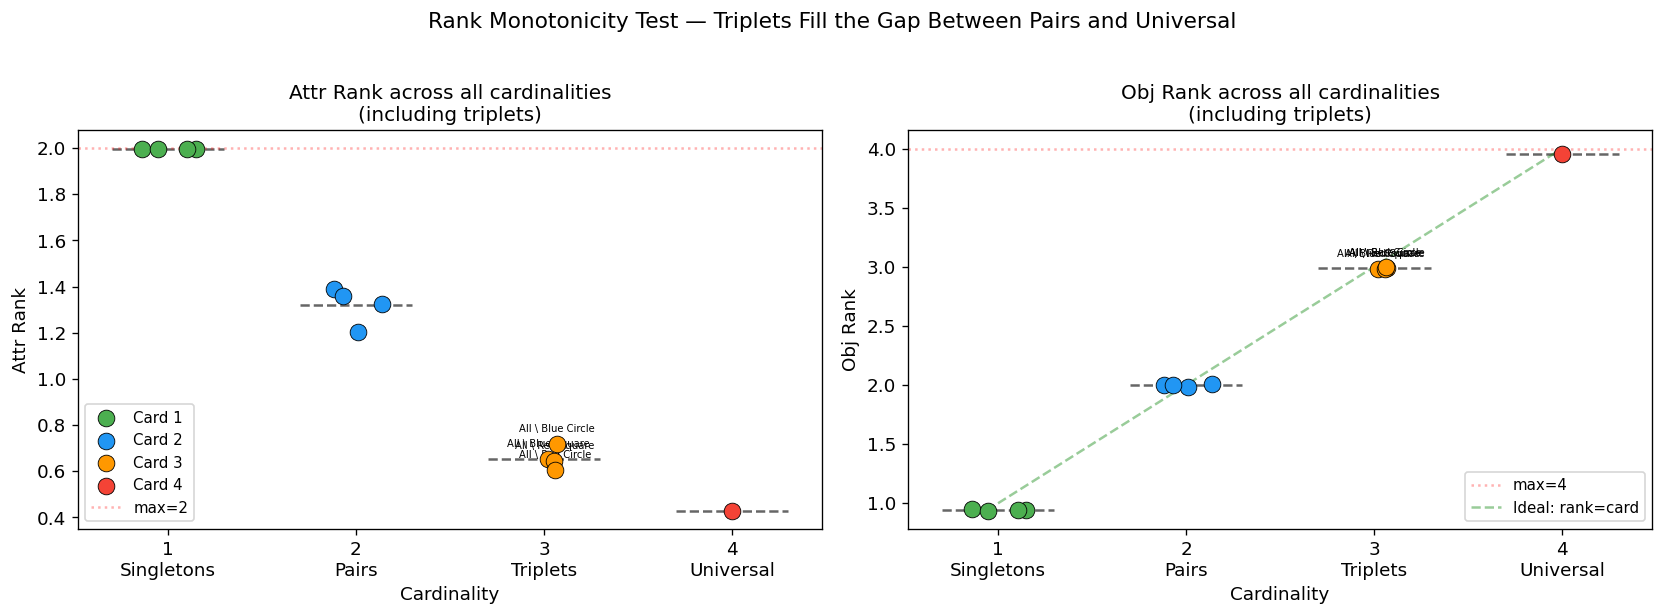

In [20]:
# Visualize triplet ranks in context of the full cardinality spectrum
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Collect all concepts by cardinality
all_names_extended = ordered_names + triplet_names
all_concepts_extended = {**concepts, **triplet_concepts}

card_to_attr = {1: [], 2: [], 3: [], 4: []}
card_to_obj = {1: [], 2: [], 3: [], 4: []}
card_to_names = {1: [], 2: [], 3: [], 4: []}

for name in all_names_extended:
    c = all_concepts_extended[name]["cardinality"]
    card_to_attr[c].append(torch.trace(all_concepts_extended[name]["P_attr"]).item())
    card_to_obj[c].append(torch.trace(all_concepts_extended[name]["P_obj"]).item())
    card_to_names[c].append(name)

# Scatter with jitter
for card in [1, 2, 3, 4]:
    jitter = np.random.uniform(-0.15, 0.15, len(card_to_attr[card]))
    color = {1: "#4CAF50", 2: "#2196F3", 3: "#FF9800", 4: "#F44336"}[card]
    ax1.scatter(card + jitter, card_to_attr[card], s=100, c=color, edgecolors="black",
                linewidth=0.5, zorder=5, label=f"Card {card}" if card == 3 else f"Card {card}")
    ax2.scatter(card + jitter, card_to_obj[card], s=100, c=color, edgecolors="black",
                linewidth=0.5, zorder=5)
    for j, name in enumerate(card_to_names[card]):
        short = name.replace("All \\ ", "\\").replace(" ", "\n") if card == 3 else ""
        if card == 3:
            ax1.annotate(name, (card + jitter[j], card_to_attr[card][j]),
                         fontsize=6, ha="center", va="bottom", xytext=(0, 6),
                         textcoords="offset points")
            ax2.annotate(name, (card + jitter[j], card_to_obj[card][j]),
                         fontsize=6, ha="center", va="bottom", xytext=(0, 6),
                         textcoords="offset points")

# Add mean lines per cardinality
for card in [1, 2, 3, 4]:
    ax1.plot([card - 0.3, card + 0.3],
             [np.mean(card_to_attr[card])] * 2, "k--", linewidth=1.5, alpha=0.6)
    ax2.plot([card - 0.3, card + 0.3],
             [np.mean(card_to_obj[card])] * 2, "k--", linewidth=1.5, alpha=0.6)

# Ideal reference lines
ax1.set_xlabel("Cardinality")
ax1.set_ylabel("Attr Rank")
ax1.set_title("Attr Rank across all cardinalities\n(including triplets)", fontsize=12)
ax1.set_xticks([1, 2, 3, 4])
ax1.set_xticklabels(["1\nSingletons", "2\nPairs", "3\nTriplets", "4\nUniversal"])
ax1.axhline(y=model.n_attr, color="red", linestyle=":", alpha=0.3, label=f"max={model.n_attr}")
ax1.legend(fontsize=9)

ax2.set_xlabel("Cardinality")
ax2.set_ylabel("Obj Rank")
ax2.set_title("Obj Rank across all cardinalities\n(including triplets)", fontsize=12)
ax2.set_xticks([1, 2, 3, 4])
ax2.set_xticklabels(["1\nSingletons", "2\nPairs", "3\nTriplets", "4\nUniversal"])
ax2.axhline(y=model.n_obj, color="red", linestyle=":", alpha=0.3, label=f"max={model.n_obj}")
# Plot ideal proportionality line for obj rank
ax2.plot([1, 4], [1, 4], "g--", alpha=0.4, linewidth=1.5, label="Ideal: rank=card")
ax2.legend(fontsize=9)

plt.suptitle("Rank Monotonicity Test — Triplets Fill the Gap Between Pairs and Universal",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

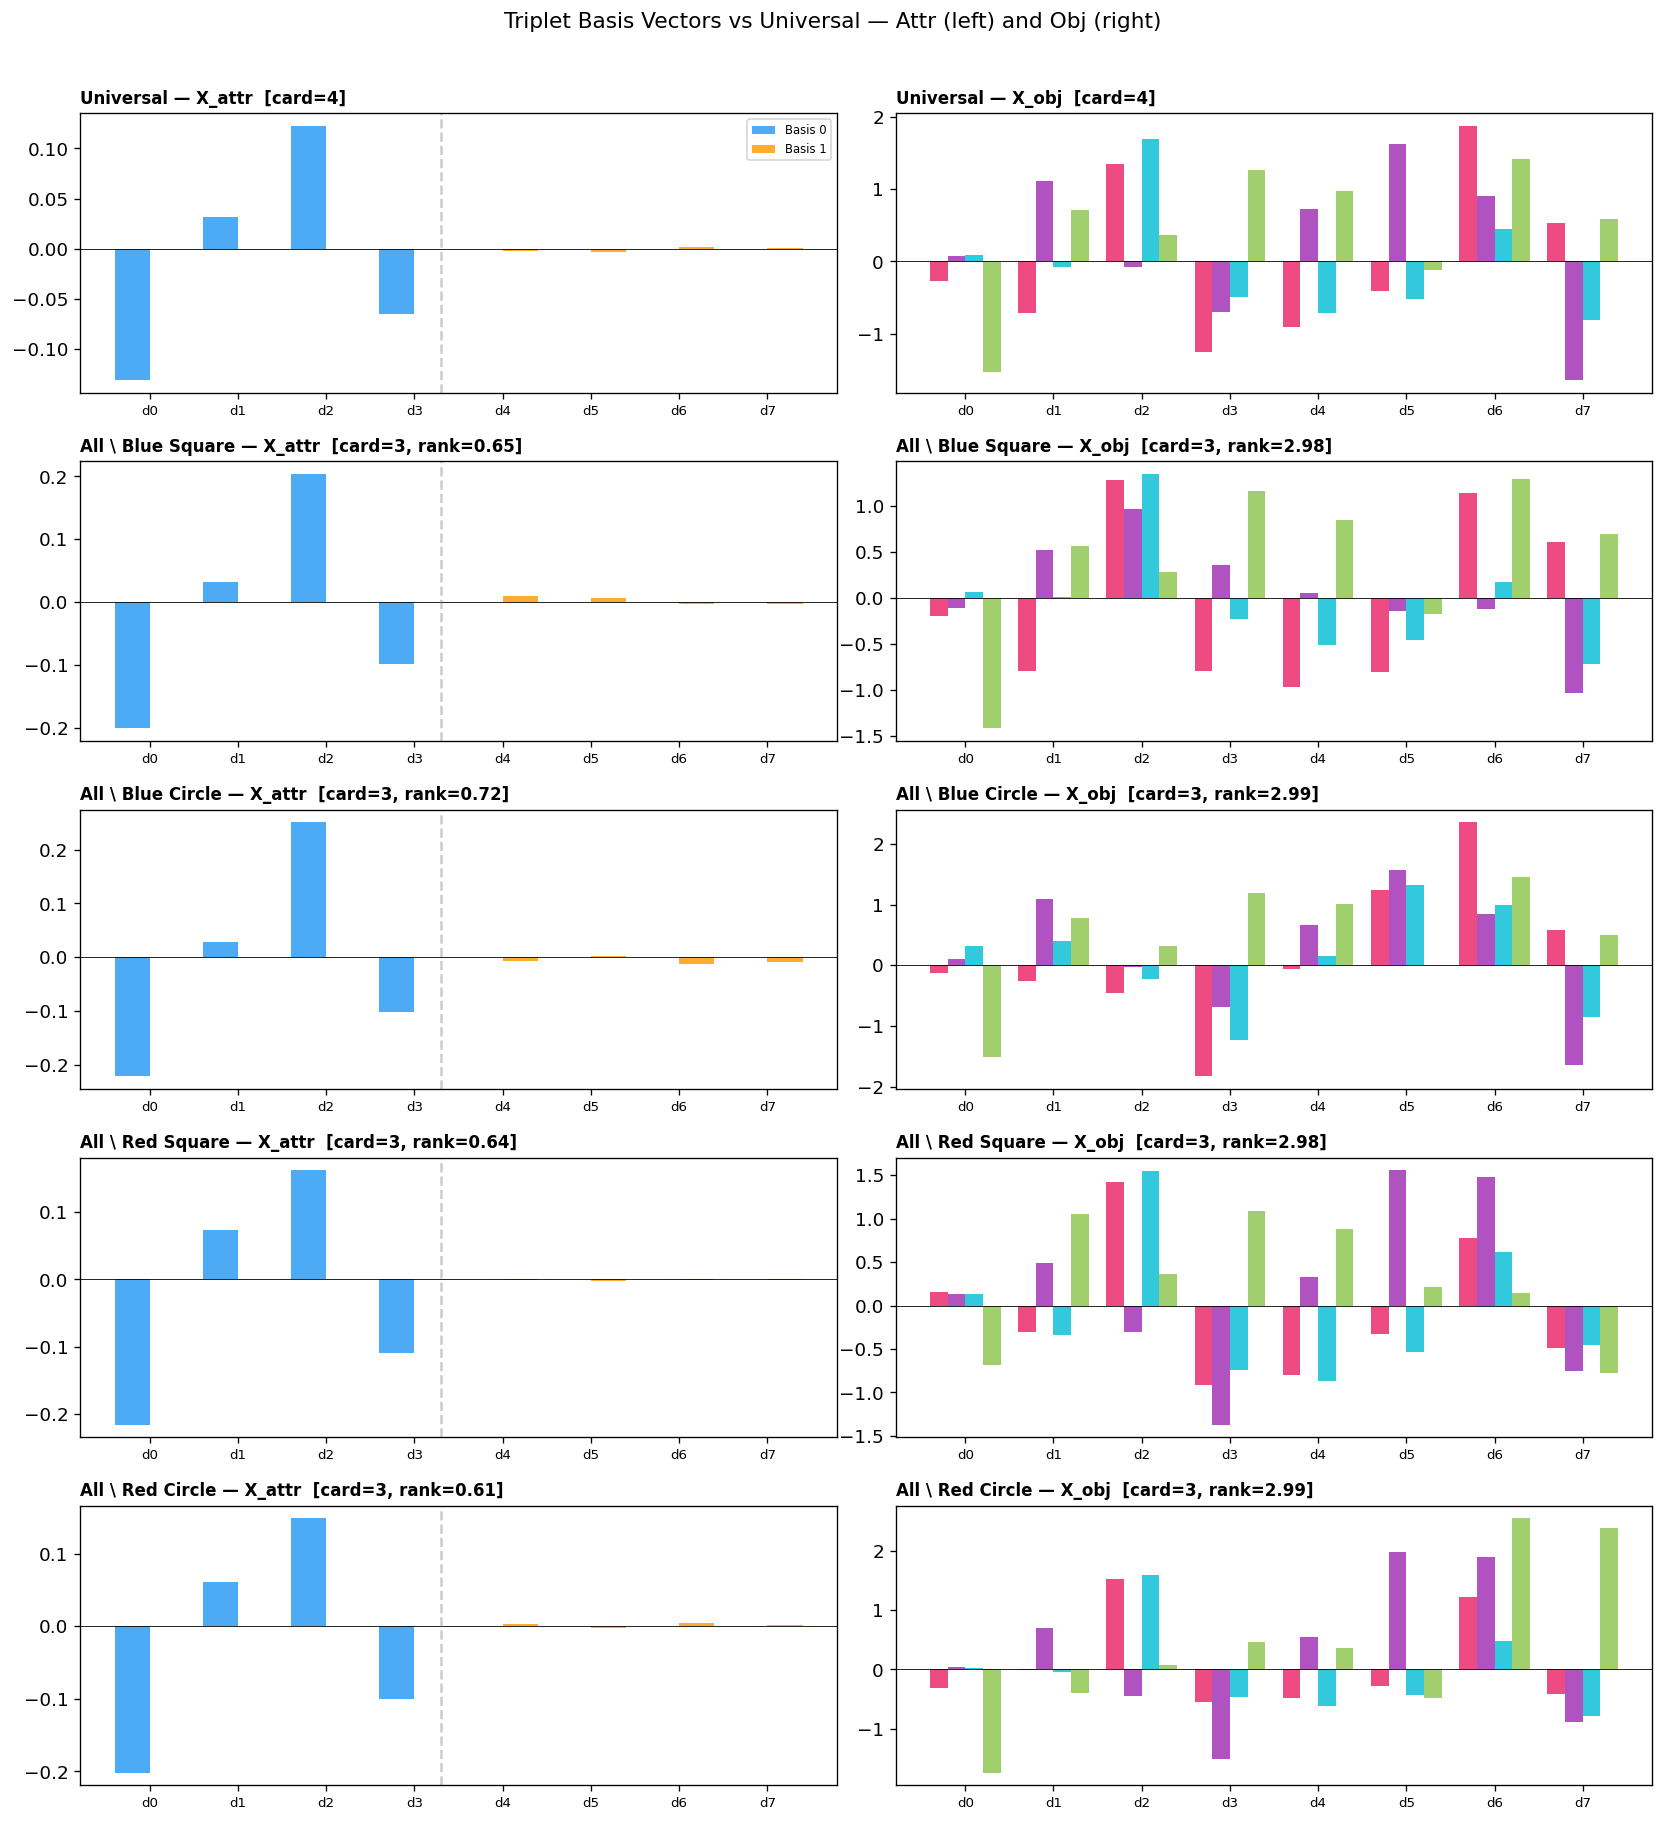

In [21]:
# Triplet attr basis vectors — compare to Universal
fig, axes = plt.subplots(len(triplet_names) + 1, 2, figsize=(14, 3 * (len(triplet_names) + 1)))

slot_colors = ["#2196F3", "#FF9800"]
dim_labels = [f"d{i}" for i in range(model.ambient_dim)]

# Universal in top row
for col, (space, key) in enumerate([(concepts["Universal"]["X_attr"], "X_attr"),
                                     (concepts["Universal"]["X_obj"], "X_obj")]):
    ax = axes[0, col]
    data = space.numpy()
    n_basis = data.shape[0]
    x = np.arange(model.ambient_dim)
    bw = 0.8 / n_basis
    colors = slot_colors if key == "X_attr" else ["#E91E63", "#9C27B0", "#00BCD4", "#8BC34A"]
    for b in range(n_basis):
        ax.bar(x + b * bw, data[b], width=bw, color=colors[b % len(colors)], alpha=0.8,
               label=f"Basis {b}")
    ax.set_title(f"Universal — {key}  [card=4]", fontsize=10, fontweight="bold", loc="left")
    ax.set_xticks(x + bw * (n_basis - 1) / 2)
    ax.set_xticklabels(dim_labels, fontsize=8)
    ax.axhline(y=0, color="black", linewidth=0.5)
    if key == "X_attr":
        ax.axvline(x=3.5, color="gray", linestyle="--", alpha=0.4)
    if col == 0:
        ax.legend(fontsize=7, loc="upper right")

# Triplets in remaining rows
for row_offset, name in enumerate(triplet_names):
    tc = triplet_concepts[name]
    for col, (space, key) in enumerate([(tc["X_attr"], "X_attr"), (tc["X_obj"], "X_obj")]):
        ax = axes[row_offset + 1, col]
        data = space.numpy()
        n_basis = data.shape[0]
        x = np.arange(model.ambient_dim)
        bw = 0.8 / n_basis
        colors = slot_colors if key == "X_attr" else ["#E91E63", "#9C27B0", "#00BCD4", "#8BC34A"]
        for b in range(n_basis):
            ax.bar(x + b * bw, data[b], width=bw, color=colors[b % len(colors)], alpha=0.8)
        ar = torch.trace(tc["P_attr"]).item() if key == "X_attr" else torch.trace(tc["P_obj"]).item()
        ax.set_title(f"{name} — {key}  [card=3, rank={ar:.2f}]",
                     fontsize=10, fontweight="bold", loc="left")
        ax.set_xticks(x + bw * (n_basis - 1) / 2)
        ax.set_xticklabels(dim_labels, fontsize=8)
        ax.axhline(y=0, color="black", linewidth=0.5)
        if key == "X_attr":
            ax.axvline(x=3.5, color="gray", linestyle="--", alpha=0.4)

plt.suptitle("Triplet Basis Vectors vs Universal — Attr (left) and Obj (right)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [22]:
# Union/intersection consistency for triplets
# Obj: triplet P_obj should ≈ union of its 3 singleton obj subspaces (expect rank ~3)
# Attr: triplet P_attr should ≈ intersection of its 3 singleton attr subspaces (expect rank < pairs)

print("Triplet Composition Analysis")
print("=" * 90)

for name in triplet_names:
    tc = triplet_concepts[name]
    member_names = [singleton_labels[i] for i in tc["indices"]]
    member_concept_names = [n for n in ordered_names if concept_cardinalities[n] == 1
                           and concept_defs[n][0] in tc["indices"]]

    # Object union
    X_obj_parts = [concepts[cn]["X_obj"] for cn in member_concept_names]
    X_obj_union = torch.cat(X_obj_parts, dim=0)
    P_union = ridge_projector(X_obj_union.unsqueeze(0), lbd=model.lbd).squeeze(0)
    P_obj_learned = tc["P_obj"]

    incl_l_in_u = get_inclusion(P_obj_learned.unsqueeze(0), P_union.unsqueeze(0)).item()
    incl_u_in_l = get_inclusion(P_union.unsqueeze(0), P_obj_learned.unsqueeze(0)).item()
    rank_union = torch.trace(P_union).item()
    rank_obj_learned = torch.trace(P_obj_learned).item()

    # Attr intersection (power method with 3 singletons)
    P_attrs = [concepts[cn]["P_attr"] for cn in member_concept_names]
    P_avg = sum(P_attrs) / len(P_attrs)
    P_inter = torch.linalg.matrix_power(P_avg, 5)
    P_attr_learned = tc["P_attr"]

    incl_la_in_i = get_inclusion(P_attr_learned.unsqueeze(0), P_inter.unsqueeze(0)).item()
    incl_i_in_la = get_inclusion(P_inter.unsqueeze(0), P_attr_learned.unsqueeze(0)).item()
    rank_inter = torch.trace(P_inter).item()
    rank_attr_learned = torch.trace(P_attr_learned).item()

    print(f"\n{name}  ({', '.join(member_concept_names)})")
    print(f"  OBJ  — Learned rank: {rank_obj_learned:.3f}, Union rank: {rank_union:.3f}")
    print(f"         incl(learned ⊆ union): {incl_l_in_u:.3f}, incl(union ⊆ learned): {incl_u_in_l:.3f}")
    print(f"  ATTR — Learned rank: {rank_attr_learned:.3f}, Intersection rank: {rank_inter:.3f}")
    print(f"         incl(learned ⊆ inter): {incl_la_in_i:.3f}, incl(inter ⊆ learned): {incl_i_in_la:.3f}")

Triplet Composition Analysis

All \ Blue Square  (Red Circle, Red Square, Blue Circle)
  OBJ  — Learned rank: 2.980, Union rank: 2.823
         incl(learned ⊆ union): 0.938, incl(union ⊆ learned): 0.990
  ATTR — Learned rank: 0.652, Intersection rank: 0.770
         incl(learned ⊆ inter): 0.649, incl(inter ⊆ learned): 0.549

All \ Blue Circle  (Red Circle, Red Square, Blue Square)
  OBJ  — Learned rank: 2.987, Union rank: 2.828
         incl(learned ⊆ union): 0.941, incl(union ⊆ learned): 0.993
  ATTR — Learned rank: 0.718, Intersection rank: 0.806
         incl(learned ⊆ inter): 0.659, incl(inter ⊆ learned): 0.587

All \ Red Square  (Red Circle, Blue Circle, Blue Square)
  OBJ  — Learned rank: 2.982, Union rank: 2.813
         incl(learned ⊆ union): 0.934, incl(union ⊆ learned): 0.990
  ATTR — Learned rank: 0.644, Intersection rank: 0.799
         incl(learned ⊆ inter): 0.670, incl(inter ⊆ learned): 0.540

All \ Red Circle  (Red Square, Blue Circle, Blue Square)
  OBJ  — Learned rank: